# Introduction to Python for Scientists
## Short Crash Course

This notebook covers the essential Python concepts you'll need as an scientist.

**What we'll cover:**
1. Variables and Data Types
2. Lists and Data Structures
3. Control Flow (if/else, loops)
4. Functions
5. NumPy Basics
6. Plotting with Matplotlib
7. Practical Engineering Example

## 1. Variables and Basic Data Types

Python uses dynamic typing - you don't need to declare variable types.

In [1]:
# Numbers
density = 1.85  # float (decimal)
samples = 42    # integer

# Strings
material = 'Isographite'
manufacturer = 'Morgan'

# Boolean
is_tested = True

print(f"Material: {material}, Density: {density} g/cm³, Samples: {samples}")
print(f"Type of density: {type(density)}")

Material: Isographite, Density: 1.85 g/cm³, Samples: 42
Type of density: <class 'float'>


In [2]:
# Basic arithmetic
force = 1000  # N
area = 0.01   # m²

stress = force / area  # Pa
print(f"Stress: {stress} Pa = {stress/1e6} MPa")

# Powers and roots
volume = 2**3  # 2 cubed
side_length = volume**(1/3)  # cube root
print(f"Volume: {volume}, Side length: {side_length}")

Stress: 100000.0 Pa = 0.1 MPa
Volume: 8, Side length: 2.0


## 2. Lists and Data Structures

Lists are ordered collections that can hold any type of data.

In [3]:
# Creating lists
temperatures = [20, 100, 200, 300, 400, 500]  # °C
manufacturers = ['Morgan', 'CarbonX', 'The Graphite Company']

print(f"First temperature: {temperatures[0]}°C")  # Indexing starts at 0
print(f"Last temperature: {temperatures[-1]}°C")  # Negative indexing from end
print(f"First three temps: {temperatures[0:3]}")  # Slicing [start:end]

# Adding elements
temperatures.append(600)
print(f"Updated temperatures: {temperatures}")

First temperature: 20°C
Last temperature: 500°C
First three temps: [20, 100, 200]
Updated temperatures: [20, 100, 200, 300, 400, 500, 600]


In [5]:
# Dictionaries - key-value pairs (very useful for material properties!)
graphite_properties = {
    'density': 1.85,
    'grain_size': 25,
    'resistivity': 12.5,
    'cte': 4.2,
    'manufacturer': 'Morgan Advanced Materials'
}

print(f"Density: {graphite_properties['density']} g/cm³")
print(f"All properties: {graphite_properties.keys()}")

# Adding new property
graphite_properties['thermal_conductivity'] = 120
print(graphite_properties)

Density: 1.85 g/cm³
All properties: dict_keys(['density', 'grain_size', 'resistivity', 'cte', 'manufacturer'])
{'density': 1.85, 'grain_size': 25, 'resistivity': 12.5, 'cte': 4.2, 'manufacturer': 'Morgan Advanced Materials', 'thermal_conductivity': 120}


## 3. Control Flow

### If/Else Statements

In [6]:
# Checking material specifications
measured_density = 1.92
spec_min = 1.80
spec_max = 2.00

if measured_density < spec_min:
    print("FAIL: Density too low")
elif measured_density > spec_max:
    print("FAIL: Density too high")
else:
    print("PASS: Density within specification")

# Inline if statement
status = "PASS" if spec_min <= measured_density <= spec_max else "FAIL"
print(f"Status: {status}")

PASS: Density within specification
Status: PASS


### Loops

In [7]:
# For loop - iterating over a list
test_loads = [100, 200, 300, 400, 500]  # N

for load in test_loads:
    stress = load / area
    print(f"Load: {load} N → Stress: {stress:.2f} Pa")

# For loop with range
print("\nTime series:")
for i in range(5):  # 0, 1, 2, 3, 4
    time = i * 0.5
    print(f"t = {time} s")

Load: 100 N → Stress: 10000.00 Pa
Load: 200 N → Stress: 20000.00 Pa
Load: 300 N → Stress: 30000.00 Pa
Load: 400 N → Stress: 40000.00 Pa
Load: 500 N → Stress: 50000.00 Pa

Time series:
t = 0.0 s
t = 0.5 s
t = 1.0 s
t = 1.5 s
t = 2.0 s


In [ ]:
# While loop
temperature = 20
target_temp = 500
heating_rate = 100  # °C per step

step = 0
while temperature < target_temp:
    print(f"Step {step}: T = {temperature}°C")
    temperature += heating_rate
    step += 1
    
print(f"Target reached at step {step}")

In [ ]:
# List comprehension - elegant way to create lists
celsius = [0, 20, 40, 60, 80, 100]

# Convert to Fahrenheit
fahrenheit = [(c * 9/5) + 32 for c in celsius]
print(f"Celsius: {celsius}")
print(f"Fahrenheit: {fahrenheit}")

# With condition
high_temps = [c for c in celsius if c > 50]
print(f"Temperatures > 50°C: {high_temps}")

## 4. Functions

Functions help you organize and reuse code.

In [8]:
# Basic function
def calculate_stress(force, area):
    """Calculate stress from force and area."""
    stress = force / area
    return stress

# Using the function
result = calculate_stress(1500, 0.01)
print(f"Stress: {result} Pa")

Stress: 150000.0 Pa


In [ ]:
# Function with default arguments
def calculate_thermal_expansion(length, temp_change, cte=4.5e-6):
    """
    Calculate thermal expansion.
    
    Parameters:
    -----------
    length : float
        Original length (m)
    temp_change : float
        Temperature change (K or °C)
    cte : float, optional
        Coefficient of thermal expansion (1/K), default for graphite
    
    Returns:
    --------
    float : Change in length (m)
    """
    delta_length = length * cte * temp_change
    return delta_length

# Using the function
L0 = 1.0  # m
dT = 300  # K

expansion = calculate_thermal_expansion(L0, dT)
print(f"Thermal expansion: {expansion*1000:.3f} mm")

# With custom CTE
expansion_steel = calculate_thermal_expansion(L0, dT, cte=12e-6)
print(f"Steel expansion: {expansion_steel*1000:.3f} mm")

In [ ]:
# Function returning multiple values
def analyze_specimen(force, area, length):
    """Calculate stress and strain."""
    stress = force / area
    strain = length / 100  # simplified
    return stress, strain

# Unpacking multiple returns
sigma, epsilon = analyze_specimen(1000, 0.01, 0.5)
print(f"Stress: {sigma} Pa, Strain: {epsilon}")

## 5. NumPy Basics

NumPy is essential for numerical computing in Python.

In [9]:
import numpy as np

# Creating arrays
temps = np.array([20, 100, 200, 300, 400, 500])
print(f"Temperatures: {temps}")

# Array operations (vectorized - much faster than loops!)
temps_kelvin = temps + 273.15
print(f"In Kelvin: {temps_kelvin}")

# Array creation functions
zeros = np.zeros(5)
ones = np.ones(5)
range_array = np.arange(0, 10, 2)  # start, stop, step
print(f"Arange: {range_array}")

linspace = np.linspace(0, 100, 11)  # start, stop, number of points
print(f"Linspace: {linspace}")

Temperatures: [ 20 100 200 300 400 500]
In Kelvin: [293.15 373.15 473.15 573.15 673.15 773.15]
Arange: [0 2 4 6 8]
Linspace: [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]


In [10]:
np.arange(0, 10, 2)

array([0, 2, 4, 6, 8])

In [11]:
np.linspace(0, 100, 11)

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.])

In [12]:
# Mathematical operations
data = np.array([1.82, 1.85, 1.88, 1.84, 1.86, 1.87])

mean = np.mean(data)
std = np.std(data)
minimum = np.min(data)
maximum = np.max(data)

print(f"Mean: {mean:.3f}")
print(f"Std Dev: {std:.4f}")
print(f"Range: [{minimum}, {maximum}]")

# Useful functions
forces = np.array([100, 200, 300, 400, 500])
sqrt_forces = np.sqrt(forces)
log_forces = np.log10(forces)
print(f"Square roots: {sqrt_forces}")

Mean: 1.853
Std Dev: 0.0197
Range: [1.82, 1.88]
Square roots: [10.         14.14213562 17.32050808 20.         22.36067977]


In [ ]:
# 2D arrays (matrices)
stress_strain_data = np.array([
    [0, 0],
    [10, 0.001],
    [20, 0.002],
    [30, 0.003],
    [40, 0.004]
])

print(f"Data shape: {stress_strain_data.shape}")  # (5, 2)
print(f"\nFirst row: {stress_strain_data[0, :]}")
print(f"Stress column: {stress_strain_data[:, 0]}")
print(f"Strain column: {stress_strain_data[:, 1]}")

## 6. Plotting with Matplotlib

Visualizing data is crucial in science.

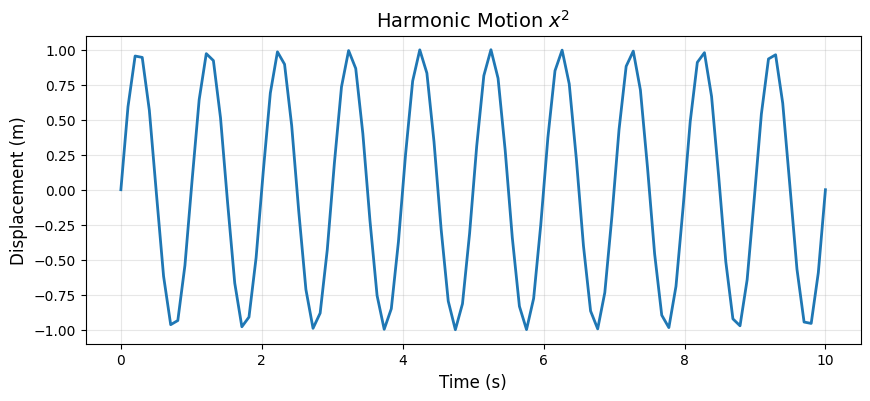

In [18]:
import matplotlib.pyplot as plt

# Basic line plot
time = np.linspace(0, 10, 100)
displacement = np.sin(2 * np.pi * time)

plt.figure(figsize=(10, 4))
plt.plot(time, displacement, linewidth=2)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Displacement (m)', fontsize=12)
plt.title(r'Harmonic Motion $x^2$', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Stress-strain curve
strain = np.array([0, 0.001, 0.002, 0.003, 0.004, 0.005])
stress = np.array([0, 20, 40, 60, 80, 100])  # MPa

plt.figure(figsize=(8, 6))
plt.plot(strain, stress, 'o-', linewidth=2, markersize=8, label='Experimental data')
plt.xlabel('Strain', fontsize=12)
plt.ylabel('Stress (MPa)', fontsize=12)
plt.title('Stress-Strain Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate Young's modulus (slope of linear region)
E = (stress[2] - stress[1]) / (strain[2] - strain[1])
print(f"Young's Modulus: {E/1000:.1f} GPa")

In [ ]:
# Multiple plots
temperature = np.linspace(20, 500, 50)
thermal_conductivity = 120 - 0.05 * temperature  # Simplified model
resistivity = 10 + 0.01 * temperature  # Simplified model

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left plot
ax1.plot(temperature, thermal_conductivity, 'r-', linewidth=2)
ax1.set_xlabel('Temperature (°C)', fontsize=11)
ax1.set_ylabel('Thermal Conductivity (W/m·K)', fontsize=11)
ax1.set_title('Thermal Conductivity vs Temperature')
ax1.grid(True, alpha=0.3)

# Right plot
ax2.plot(temperature, resistivity, 'b-', linewidth=2)
ax2.set_xlabel('Temperature (°C)', fontsize=11)
ax2.set_ylabel('Resistivity (μΩ·m)', fontsize=11)
ax2.set_title('Resistivity vs Temperature')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Practical Engineering Example

### Heat Transfer in a Rod

Let's solve a simple 1D heat conduction problem using finite differences.

In [ ]:
# Problem setup: 1D steady-state heat conduction in a rod
# T(0) = 100°C, T(L) = 20°C

# Parameters
L = 1.0  # Length (m)
T_hot = 100  # °C
T_cold = 20  # °C
n_points = 21  # Number of discretization points

# Create position array
x = np.linspace(0, L, n_points)
dx = x[1] - x[0]

# Analytical solution (for validation)
T_analytical = T_hot - (T_hot - T_cold) * x / L

print(f"Grid spacing: {dx*100:.2f} cm")
print(f"Temperature at x=0: {T_analytical[0]:.1f}°C")
print(f"Temperature at x=L: {T_analytical[-1]:.1f}°C")
print(f"Temperature at midpoint: {T_analytical[n_points//2]:.1f}°C")

In [ ]:
# Plot the temperature distribution
plt.figure(figsize=(10, 6))
plt.plot(x, T_analytical, 'b-', linewidth=2, label='Analytical solution')
plt.plot(x, T_analytical, 'ro', markersize=6, label='Discretization points')
plt.xlabel('Position (m)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('1D Steady-State Heat Conduction in a Rod', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate heat flux using Fourier's law: q = -k * dT/dx
k = 120  # Thermal conductivity of graphite (W/m·K)

# Temperature gradient (numerical derivative)
dT_dx = np.gradient(T_analytical, x)
heat_flux = -k * dT_dx

print(f"Temperature gradient: {dT_dx[0]:.2f} K/m")
print(f"Heat flux (constant for linear T): {heat_flux[0]:.2f} W/m²")

# Plot heat flux
plt.figure(figsize=(10, 5))
plt.plot(x, heat_flux, 'g-', linewidth=2)
plt.xlabel('Position (m)', fontsize=12)
plt.ylabel('Heat Flux (W/m²)', fontsize=12)
plt.title('Heat Flux Distribution', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=np.mean(heat_flux), color='r', linestyle='--', label='Mean flux')
plt.legend()
plt.tight_layout()
plt.show()

## Exercise: Try it yourself!

**Problem**: A cylindrical graphite specimen is subjected to compression testing.

Given:
- Diameter: 25 mm
- Applied forces: [0, 5000, 10000, 15000, 20000, 25000] N
- Measured displacements: [0, 0.05, 0.10, 0.15, 0.20, 0.25] mm
- Original length: 50 mm

Tasks:
1. Calculate the cross-sectional area
2. Calculate stress for each force
3. Calculate strain for each displacement
4. Plot the stress-strain curve
5. Calculate the elastic modulus (slope of the curve)

Use the code cells below:

In [ ]:
# Your code here
# Hint: Area of circle = π * r²
# Stress = Force / Area
# Strain = ΔL / L₀


In [ ]:
# Solution (don't peek until you try!)

# Given data
diameter = 25e-3  # m
forces = np.array([0, 5000, 10000, 15000, 20000, 25000])  # N
displacements = np.array([0, 0.05, 0.10, 0.15, 0.20, 0.25]) * 1e-3  # m
L0 = 50e-3  # m

# Calculate area
radius = diameter / 2
area = np.pi * radius**2
print(f"Cross-sectional area: {area*1e6:.2f} mm²")

# Calculate stress and strain
stress = forces / area  # Pa
stress_MPa = stress / 1e6  # Convert to MPa
strain = displacements / L0  # dimensionless

# Plot
plt.figure(figsize=(8, 6))
plt.plot(strain, stress_MPa, 'o-', linewidth=2, markersize=8)
plt.xlabel('Strain', fontsize=12)
plt.ylabel('Stress (MPa)', fontsize=12)
plt.title('Compressive Stress-Strain Curve for Graphite', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate elastic modulus using linear regression
coefficients = np.polyfit(strain, stress, 1)
E = coefficients[0]  # Pa
print(f"\nElastic Modulus: {E/1e9:.2f} GPa")

# Alternative: using first two points
E_manual = (stress[2] - stress[1]) / (strain[2] - strain[1])
print(f"Elastic Modulus (manual): {E_manual/1e9:.2f} GPa")

## Key Takeaways

1. **Python is dynamically typed** - no need to declare variable types
2. **Indentation matters** - it defines code blocks
3. **Lists and dictionaries** are powerful data structures
4. **NumPy** makes numerical computing efficient (vectorization!)
5. **Matplotlib** creates publication-quality plots
6. **Functions** help organize reusable code

## Next Steps

- **Pandas**: Data manipulation and analysis (like Excel on steroids)
- **SciPy**: Scientific computing (optimization, integration, signal processing)
- **SymPy**: Symbolic mathematics
- **scikit-learn**: Machine learning

## Resources

- Official Python Tutorial: https://docs.python.org/3/tutorial/
- NumPy Documentation: https://numpy.org/doc/
- Matplotlib Gallery: https://matplotlib.org/stable/gallery/
- Real Python: https://realpython.com/